# HEROS: Tree-Based Rule Population Initialization Tests

This notebook is designed to **test the decision-tree-based rule population initialization** in HEROS on two datasets:

1. **Car Evaluation** (all categorical features, each with multiple categories)  
2. **Adult Income** (mixed continuous + categorical features)

It focuses on:
- Verifying that the **categorical tree-init** works correctly on a fully categorical problem.
- Verifying that the **mixed-type tree-init** works correctly when only a subset of features are categorical (`cat_feat_indexes`).


In [6]:
# Notebook Operation Parameters ---------------------------------------------------------------
# Adjust these flags/paths as needed for your environment.

load_from_cloned_repo = True   # True if running inside the cloned HEROS GitHub repository.
local_save = True              # If True, saves output in ./output relative to this notebook.
folder_path = "./output"       # Path for output files if local_save is False.
run_all_cells = True           # If True, you can just "Run All" to execute everything.

# Random seed for reproducibility
random_state = 42


In [7]:
# Package Imports & Folder Management ---------------------------------------------------------
import os
import sys
import random

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# Ensure project root is on sys.path so that src/skheros/* can be imported when using a cloned repo
project_root = os.path.abspath("./src")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Load HEROS algorithm -------------------------------------------------------------------------
if load_from_cloned_repo:
    # Running from the cloned HEROS GitHub repository
    try:
        from src.skheros.heros import HEROS
    except ModuleNotFoundError:
        # Fallback if src.* layout is different in your environment
        from skheros.heros import HEROS
else:
    # Rely on installed package
    from skheros.heros import HEROS

# Determine notebook output folder ------------------------------------------------------------
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if local_save:
    output_path = "./output"
else:
    output_path = folder_path

print("Current working directory:", os.getcwd())
print("Output path:", output_path)

# Global random seeds --------------------------------------------------------------------------
np.random.seed(random_state)
random.seed(random_state)


Current working directory: /Users/gabe/heros
Output path: ./output


In [17]:
# Utility helpers -----------------------------------------------------------------------------


def summarize_dataset(name, X_df, y):
    """Print a quick summary of a dataset (feature types, shapes, etc.)."""
    print(f"\n=== {name} Dataset Summary ===")
    print("X shape:", X_df.shape)
    print("y shape:", y.shape)
    print("\nFirst 5 rows of X:")
    display(X_df)
    print("\nClass distribution:")
    print(pd.Series(y).value_counts(normalize=True).rename("proportion"))



## Car Evaluation Dataset (All Categorical)

We load the **UCI Car Evaluation** dataset directly from the UCI repository.

- All 6 features are **categorical** with multiple levels.
- The target (class) is also categorical with 4 categories.

We will:
1. Load the dataset into a `pandas.DataFrame`.
2. Define `cat_feat_indexes` as **all feature indices**.
3. Run HEROS with tree-based rule population initialization.


In [18]:
# Load Car Evaluation dataset -----------------------------------------------------------------
car_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"

car_columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class",   # outcome
]

car_df = pd.read_csv(car_url, names=car_columns)

# Split into X (features) and y (outcome)
outcome_label_car = "class"
X_car_df = car_df.drop(columns=[outcome_label_car])
y_car = car_df[outcome_label_car].values

# All features are categorical for this dataset
cat_feat_indexes_car = list(range(X_car_df.shape[1]))

summarize_dataset("Car Evaluation", X_car_df, y_car)

print("\nCategorical feature indexes (Car):", cat_feat_indexes_car)
print("Feature names (Car):", list(X_car_df.columns))



=== Car Evaluation Dataset Summary ===
X shape: (1728, 6)
y shape: (1728,)

First 5 rows of X:


,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med



Class distribution:
unacc    0.700231
acc      0.222222
good     0.039931
vgood    0.037616
Name: proportion, dtype: float64

Categorical feature indexes (Car): [0, 1, 2, 3, 4, 5]
Feature names (Car): ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


### Run HEROS with Tree-Based Rule Initialization on Car Dataset

Here we:

1. Instantiate a HEROS object (using relatively small iteration counts to keep this **lightweight**).
2. Call `.fit(...)` on the Car Evaluation dataset, passing `cat_feat_indexes=cat_feat_indexes_car`.
3. Optionally inspect `heros_car.rule_population` to verify that the **tree-based categorical initialization** is working as expected.

> **Note:** Adjust the hyperparameters below (iterations, population sizes, etc.) to match your experimental setup or mirror the settings in `HEROS_Demo_Notebook.ipynb`.


Data Manage Summary: ------------------------------------------------
Number of quantitative features: 0
Number of categorical features: 6
Total Features: 6
Total Instances: 1728
Feature Types: [1, 1, 1, 1, 1, 1]
Missing Values: 0
Quantiative Feature Range: [[inf, -inf], [inf, -inf], [inf, -inf], [inf, -inf], [inf, -inf], [inf, -inf]]
Categorical Feature Values: [[3.0, 0.0, 2.0, 1.0], [3.0, 0.0, 2.0, 1.0], [0.0, 1.0, 2.0, 3.0], [0.0, 1.0, 2.0], [2.0, 1.0, 0.0], [1.0, 2.0, 0.0]]
Average States: 3.5
Rule Specificity Limit: 6
Classes: [2, 0, 3, 1]
Class Counts: {2: 1210, 0: 384, 3: 65, 1: 69}
Class Weights: {2: 0.2997685185185185, 0: 0.7777777777777778, 3: 0.9623842592592593, 1: 0.9600694444444444}
Majority Class: 2
Expert Knowledge Weights Used: False
--------------------------------------------------------------------
Entering tree_init_population...
Exploratory analysis of input data:
  X shape: (1728, 6)
  y shape: (1728,)
  Feature names: N/A
  Number of classes: 4
  Class distributi

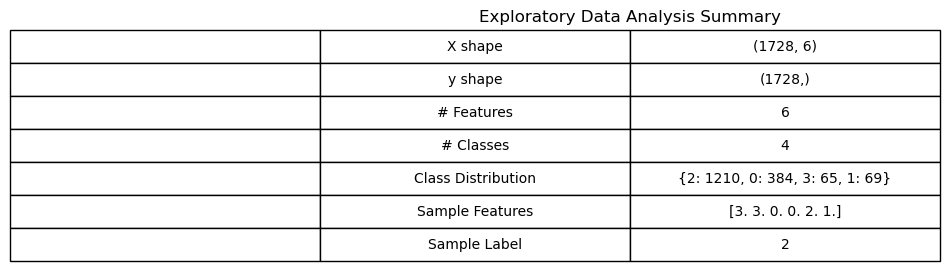


Training multiple Random Forests with diverse hyperparameters for rule extraction...

One-hot encoding 6 categorical features...
  Original features: 6, After one-hot encoding: 21
  One-hot mapping created for 21 encoded features
  Quantitative feature mapping: 0 features
  Trained RF 1: n_estimators=10, max_depth=3, random_state=42
    Tree depths: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Trained RF 2: n_estimators=10, max_depth=5, random_state=42
    Tree depths: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  Trained RF 3: n_estimators=10, max_depth=7, random_state=42
    Tree depths: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Trained RF 4: n_estimators=10, max_depth=None, random_state=42
    Tree depths: [14, 15, 15, 15, 14, 14, 14, 15, 15, 14]
  Trained RF 5: n_estimators=20, max_depth=4, random_state=42
    Tree depths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  Trained RF 6: n_estimators=20, max_depth=8, random_state=42
    Tree depths: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,

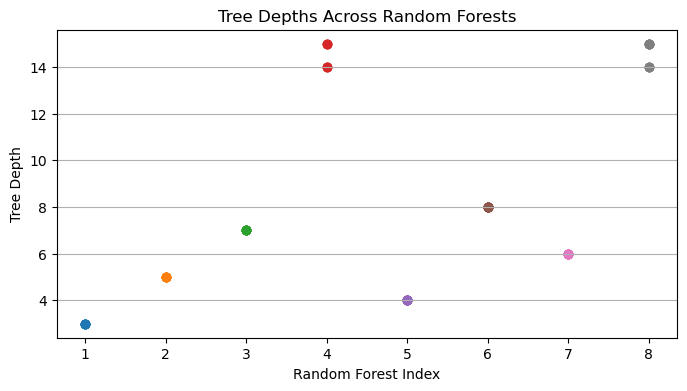


Summary: Trained 8 random forests with varying hyperparameters.
  RF 1: n_estimators=10, tree depths=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  RF 2: n_estimators=10, tree depths=[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  RF 3: n_estimators=10, tree depths=[7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  RF 4: n_estimators=10, tree depths=[14, 15, 15, 15, 14, 14, 14, 15, 15, 14]
  RF 5: n_estimators=20, tree depths=[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  RF 6: n_estimators=20, tree depths=[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  RF 7: n_estimators=15, tree depths=[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
  RF 8: n_estimators=15, tree depths=[14, 15, 15, 15, 14, 14, 14, 15, 15, 14, 15, 14, 15, 15, 15]

Extracting rules from all decision trees in all forests...
Total raw rules extracted: 9366


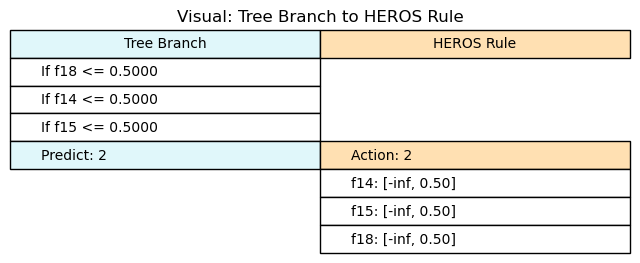

Deduplicating rules...
Unique rules after deduplication: 6806


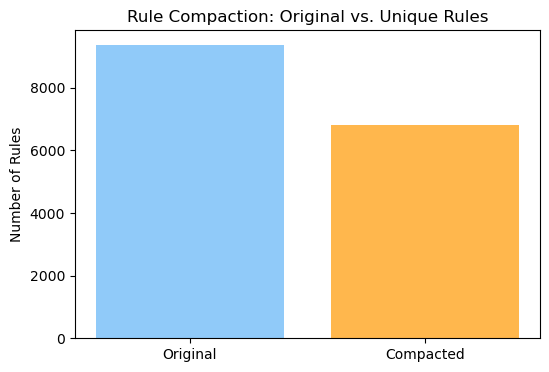


Summary: Extracted 9366 raw rules from all trees.
After deduplication, 6806 unique rules remain.

Converting extracted rules to HEROS format and checking for redundancy...
Total numerosity in population: 6722
Number of rules in correct HEROS format: 2593


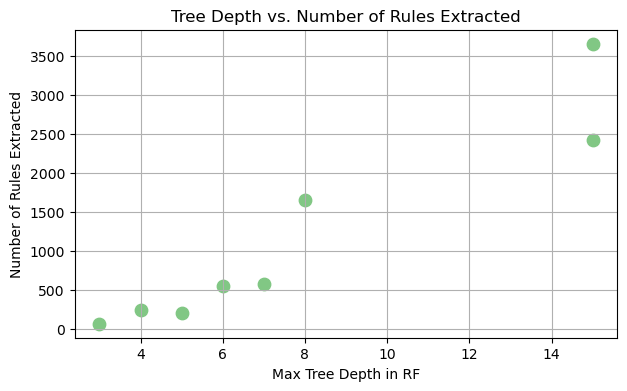


Summary: Converted rules to HEROS format and added to population.
Population numerosity: 6722
Unique HEROS rules: 2593

Calculating training accuracy of the rule population...
Training accuracy of rule population: 0.5336

Summary: Calculated training accuracy of rule population: 0.5336

Calculating random forest training accuracy for proof of fidelity...
Random Forest training accuracy: 0.7002
Rule population training accuracy: 0.5336
Difference (RF - RulePop): 0.1667

Summary: RF accuracy = 0.7002, RulePop accuracy = 0.5336, diff = 0.1667
Fidelity check WARNING (difference > 5%).

Visualizing the first decision tree in the random forest...


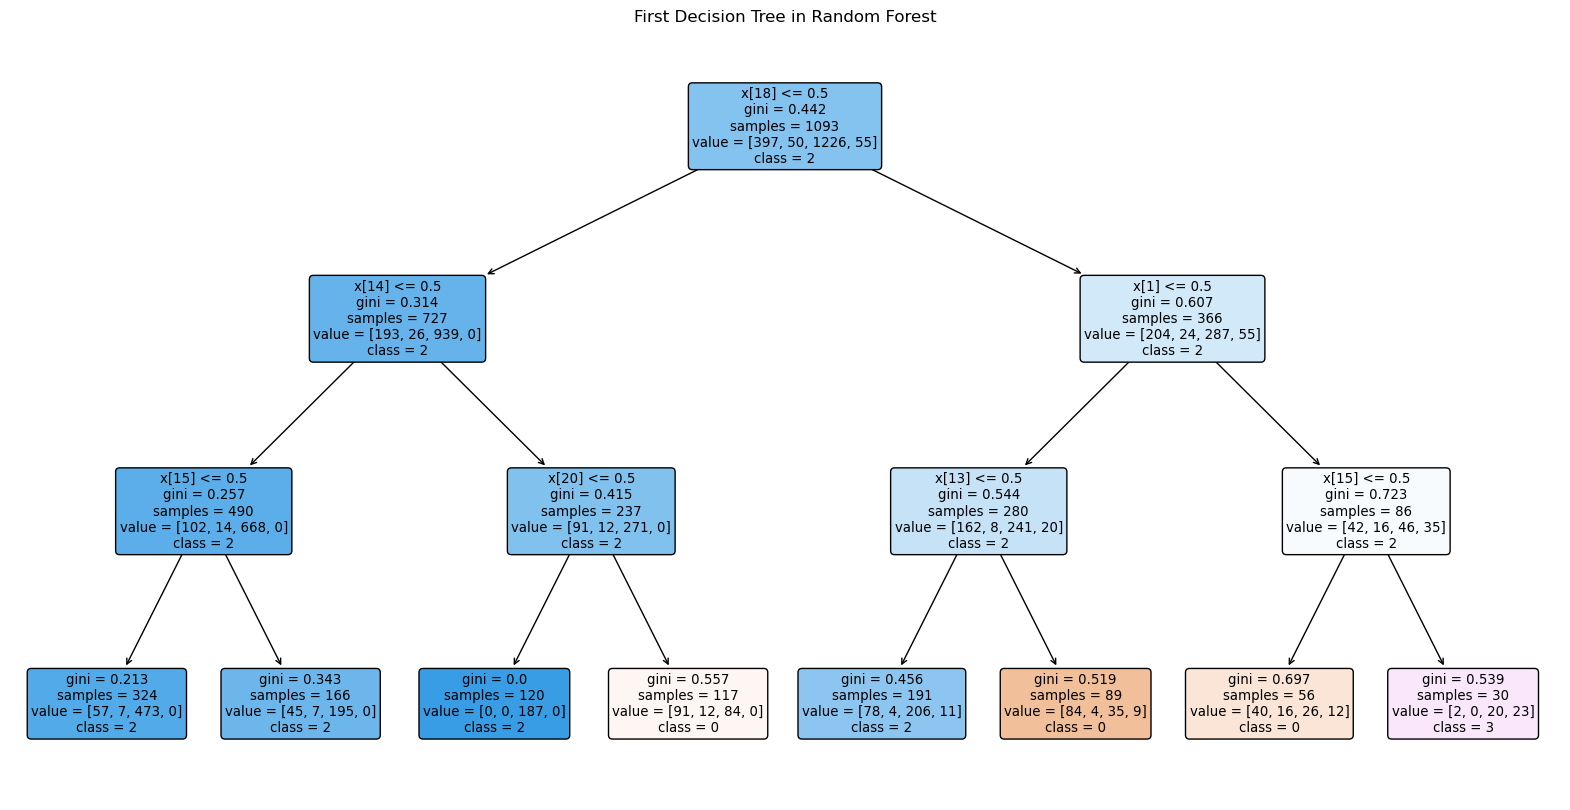

Decision tree visualization saved as 'decision_tree_visualization_matplotlib.png'

Summary: Plotted and saved the first decision tree from the random forest.

Visualizing a single branch and its corresponding rule...
Example branch path:
  If f18 <= 0.5000
  If f14 <= 0.5000
  If f15 <= 0.5000
  --> Predict class: 2
Could not visualize branch-to-rule conversion: RULE_POP.tree_init_population.<locals>.convert_path_to_minmax() missing 3 required positional arguments: 'onehot_mapping', 'quant_feat_mapping', and 'heros'

Summary: Printed a single branch from a tree and its conversion to a HEROS rule.

Printing all rule attributes for debugging:
--------------------------------------------------
ID: 0
Condition Indexes: [1, 3, 5]
Condition Values: [1.0, 1.0, 2.0]
Action: 0
Numerosity: 2
Fitness: 1.0
Useful Accuracy: 0.35714285714285715
Useful Coverage: 13.333333333333334
Accuracy: 0.5
Match Cover: 48
Correct Cover: 24
Mean Absolute Error: None
Prediction: None
Outcome Range Probability: Non

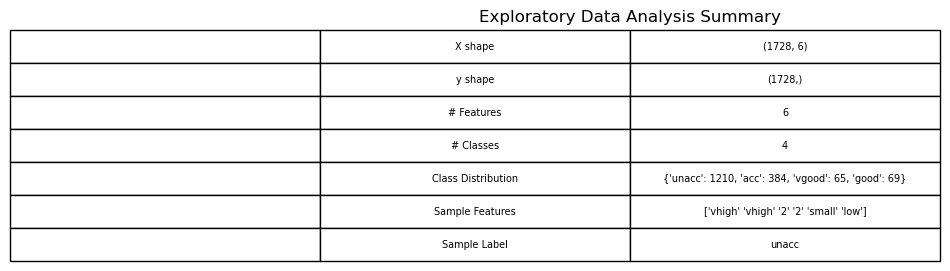


Training multiple Random Forests with diverse hyperparameters for rule extraction...

One-hot encoding 6 categorical features...
  Original features: 6, After one-hot encoding: 21
  One-hot mapping created for 21 encoded features
  Quantitative feature mapping: 0 features
  Trained RF 1: n_estimators=10, max_depth=3, random_state=42
    Tree depths: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Trained RF 2: n_estimators=10, max_depth=5, random_state=42
    Tree depths: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  Trained RF 3: n_estimators=10, max_depth=7, random_state=42
    Tree depths: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Trained RF 4: n_estimators=10, max_depth=None, random_state=42
    Tree depths: [14, 15, 15, 15, 14, 14, 14, 15, 15, 14]
  Trained RF 5: n_estimators=20, max_depth=4, random_state=42
    Tree depths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  Trained RF 6: n_estimators=20, max_depth=8, random_state=42
    Tree depths: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,

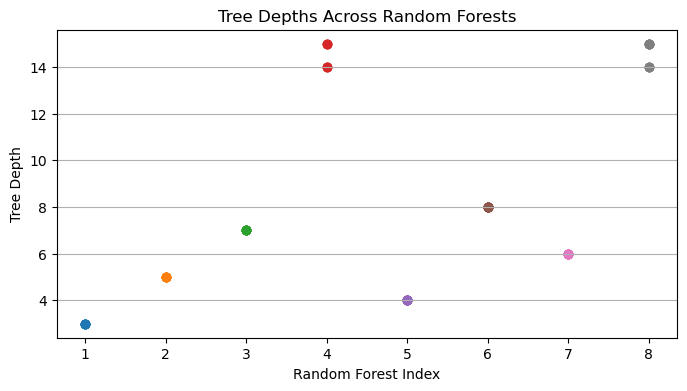


Summary: Trained 8 random forests with varying hyperparameters.
  RF 1: n_estimators=10, tree depths=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  RF 2: n_estimators=10, tree depths=[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  RF 3: n_estimators=10, tree depths=[7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  RF 4: n_estimators=10, tree depths=[14, 15, 15, 15, 14, 14, 14, 15, 15, 14]
  RF 5: n_estimators=20, tree depths=[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  RF 6: n_estimators=20, tree depths=[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  RF 7: n_estimators=15, tree depths=[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
  RF 8: n_estimators=15, tree depths=[14, 15, 15, 15, 14, 14, 14, 15, 15, 14, 15, 14, 15, 15, 15]

Extracting rules from all decision trees in all forests...
Total raw rules extracted: 9366


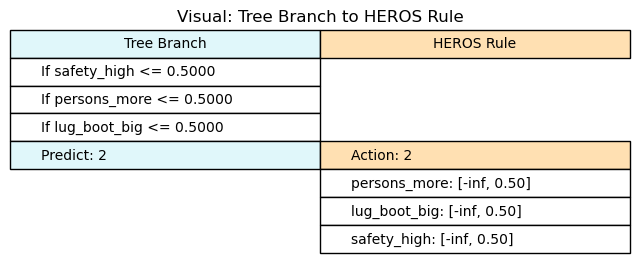

Deduplicating rules...
Unique rules after deduplication: 6806


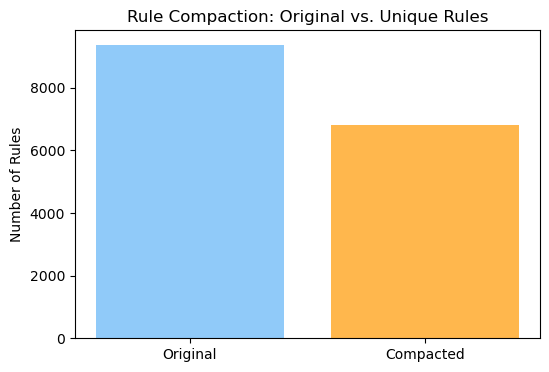


Summary: Extracted 9366 raw rules from all trees.
After deduplication, 6806 unique rules remain.

Converting extracted rules to HEROS format and checking for redundancy...
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDivisionError'>
An unexpected error occurred: division by zero
Type of unexpected exception: <class 'ZeroDiv

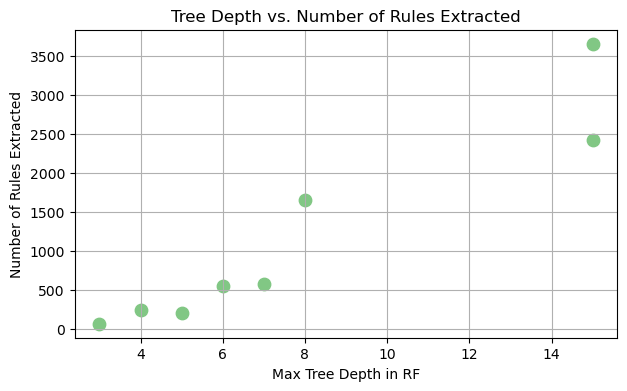


Summary: Converted rules to HEROS format and added to population.
Population numerosity: 500
Unique HEROS rules: 157

Calculating training accuracy of the rule population...
Training accuracy of rule population: 0.0000

Summary: Calculated training accuracy of rule population: 0.0000

Calculating random forest training accuracy for proof of fidelity...
Random Forest training accuracy: 0.7002
Rule population training accuracy: 0.0000
Difference (RF - RulePop): 0.7002

Summary: RF accuracy = 0.7002, RulePop accuracy = 0.0000, diff = 0.7002
Fidelity check WARNING (difference > 5%).

Visualizing the first decision tree in the random forest...


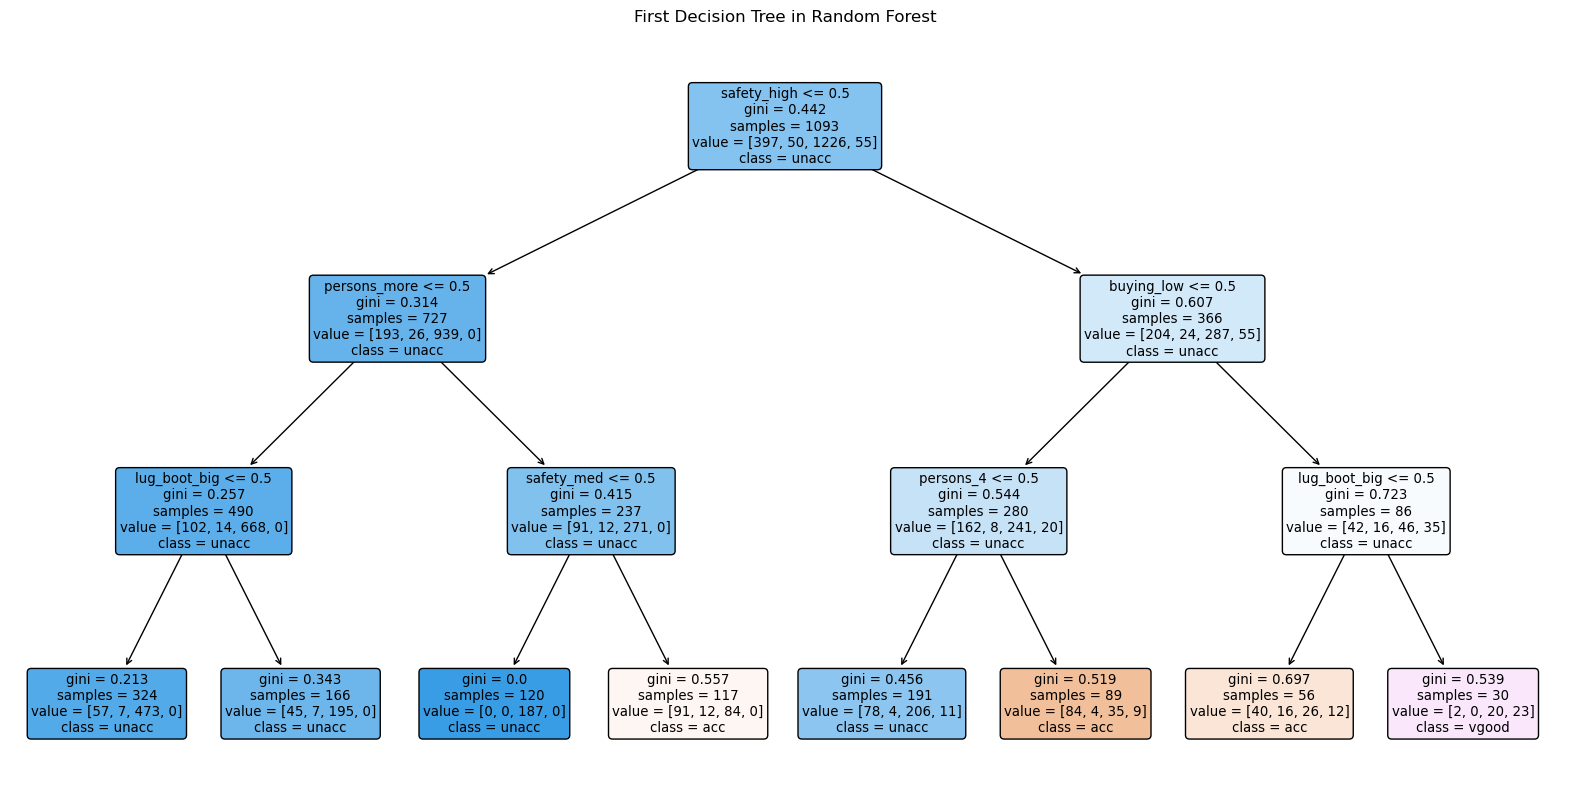

Decision tree visualization saved as 'decision_tree_visualization_matplotlib.png'

Summary: Plotted and saved the first decision tree from the random forest.

Visualizing a single branch and its corresponding rule...
Example branch path:
  If safety_high <= 0.5000
  If persons_more <= 0.5000
  If lug_boot_big <= 0.5000
  --> Predict class: 2
Could not visualize branch-to-rule conversion: RULE_POP.tree_init_population.<locals>.convert_path_to_minmax() missing 3 required positional arguments: 'onehot_mapping', 'quant_feat_mapping', and 'heros'

Summary: Printed a single branch from a tree and its conversion to a HEROS rule.

Printing all rule attributes for debugging:
--------------------------------------------------
ID: 630
Condition Indexes: [5]
Condition Values: [1.0]
Action: 2
Numerosity: 33
Fitness: 1.0
Useful Accuracy: 1.0
Useful Coverage: 172.66666666666663
Accuracy: 1.0
Match Cover: 576
Correct Cover: 576
Mean Absolute Error: None
Prediction: None
Outcome Range Probability: None

In [10]:
# HEROS hyperparameters for Car dataset (keep relatively small for quick tests) ---------------
outcome_type = "class"

# HEROS Key Hyperparameters -------------------------------------------------------------------------------------
iterations = 50000 # (Rule_I) Number of Phase I learning iterations (e.g. 50000)
pop_size = 500 # (Rule_P) Maximum size of Phase I rule population (micro-population size) (e.g. 500)
model_iterations = 100 # (Model_I) Number of Phase II learning iterations (e.g. 100)
model_pop_size = 100 # (Model_P) Maximum size of Phase II model population (e.g. 100)
nu = 1 # (v) Accuracy pressure (1 is neutral)

# Other HEROS Hyperparameters -----------------------------------------------------------------------------------
beta = 0.2 # (B) Average {M} size learning rate
theta_sel = 0.5 # (0_sel) {M} proportion for Phase I tournament selection
cross_prob = 0.8 # (p_cross) probability of applying crossover (Phase I and II)
mut_prob = 0.04 # (p_mut) probability of applying mutation (Phase I and II)
merge_prob = 0.1 # (p_merge) probability of applying merge (Phase II)
new_gen = 1.0 # Controls size of {OMP} as function of Model_P
model_pop_init = 'target_acc' # Model initialization method ('random' or 'target_acc')
subsumption = 'both' # Use GA, {C} or 'both' subsumption mechanisms ('ga', or 'c', 'both', or None)
rsl = 0 # Manually specify rule specificity limit (Give positive integer or leave 0 for automatic rule specificity limit determination from dataset properties)
compaction = 'sub' # rule compaction method ('sub' or None)
random_state = 42 # Applied random seed (for reproducibility)

# HEROS Performance tracking hyperparameters --------------------------------------------------------------------
track_performance = 1000 # Number of Phase I iterations where performance metrics are periodically estimated
model_tracking = True # Track top model performance across training iterations
stored_rule_iterations = '500,1000,5000,10000,50000' # Specified Phase I iterations where the current rule {P} is archived for external evaluation (e.g. '500,1000,5000,10000' or None)
stored_model_iterations = '10,50,100' # Specified Phase II iterations where the current {MP} is archived for external evaluation (e.g. '10,50,100', or None)
verbose = True # Run in 'verbose' mode - display run details

# In-Development HEROS Hyperparameters (Recommend not changing) -------------------------------------------------
outcome_type = 'class' # Only 'class' (i.e. classification outcome) is operational in current implementation
fitness_function = 'pareto' # Fitness function for Phase I rule discovery ('accuracy' or 'pareto') Pareto is strongly recommended unless analyzing clean problems.
feat_track = 'end' # Feature tracking strategy applied (None, 'add', 'wh', 'end') Experimental - recommended to leave to None
rule_pop_init = 'dt - verbose' # Specifies rule population pre-initialization method (None, 'load', or 'dt') Experimental - recommended to leave to None

# Instantiate HEROS ---------------------------------------------------------------------------
heros_car = HEROS(outcome_type=outcome_type,iterations=iterations,pop_size=pop_size,cross_prob=cross_prob,mut_prob=mut_prob,nu=nu,beta=beta,theta_sel=theta_sel,
              fitness_function=fitness_function,subsumption=subsumption,rsl=rsl,feat_track=feat_track, model_iterations=model_iterations,
              model_pop_size=model_pop_size,model_pop_init=model_pop_init,new_gen=new_gen,merge_prob=merge_prob,rule_pop_init=rule_pop_init,compaction=compaction,
              track_performance=track_performance,model_tracking=model_tracking,stored_rule_iterations=stored_rule_iterations,stored_model_iterations=stored_model_iterations,random_state=random_state, verbose=verbose, mode = 'equal')


# For the tree_init_population method, HEROS expects X as a numpy array,
# but the tree-based initialization code often prefers a DataFrame (for column names).
# We therefore:
#   - keep X_car_df as a DataFrame for tree-based rule extraction,
#   - and pass X_car_df.values into .fit(...).
# Encode all categorical columns into integer codes, then cast to float
X_car_encoded_df = X_car_df.apply(lambda col: pd.Categorical(col).codes)
X_car = X_car_encoded_df.to_numpy(dtype=float)

row_id_car = None
ek_car = None   # no expert knowledge for this simple test

# Fit HEROS on Car dataset --------------------------------------------------------------------
heros_car = heros_car.fit(
    X_car,
    y_car,
    row_id_car,
    cat_feat_indexes=cat_feat_indexes_car,
    ek=ek_car,
)

print("\nHEROS training on Car dataset complete.")

# Optional: directly call tree_init_population if you want a stand-alone test -----------------
try:
    # This assumes your rule_population object exposes a 'tree_init_population' method that
    # accepts (X, y, heros, random, np, verbose) as in your development code.
    print("\nRunning explicit tree_init_population on Car dataset...")
    heros_car.rule_population.tree_init_population(
        X_car_df,  # use DataFrame for feature names
        y_car,
        heros_car,
        random,
        np,
        verbose=True,
    )
    print("tree_init_population (Car) finished.")
except AttributeError as e:
    print("tree_init_population method not found on heros_car.rule_population. Skipping explicit call.")
    print("Error:", e)

# Optional: Inspect rule population summary ---------------------------------------------------
if hasattr(heros_car, "rule_population"):
    rp = heros_car.rule_population
    if hasattr(rp, "rule_pop_df"):
        print("\nFirst 10 rules from Car rule population:")
        display(rp.rule_pop_df.head(10))


## Adult Income Dataset (Mixed Continuous + Categorical)

We now load the **UCI Adult** dataset, which contains both:

- **Continuous** features (e.g., age, hours-per-week, capital-gain).
- **Categorical** features with **more than 2 categories** (e.g., workclass, education, occupation, native-country).

Steps:

1. Load the dataset from UCI.
2. Clean missing values (`' ?'`) and drop rows with NAs.
3. Identify which columns are **categorical** and construct `cat_feat_indexes_adult`.
4. Run HEROS with tree-based initialization on this mixed-type data.


In [11]:
# Load Adult Income dataset -------------------------------------------------------------------
adult_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

adult_columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",     # outcome
]

adult_df = pd.read_csv(
    adult_url,
    names=adult_columns,
    na_values=" ?",
    skipinitialspace=True,
)

# Drop rows with any missing values for simplicity
adult_df = adult_df.dropna(axis=0).reset_index(drop=True)

outcome_label_adult = "income"
X_adult_df = adult_df.drop(columns=[outcome_label_adult])
y_adult = adult_df[outcome_label_adult].values

# Define categorical features (mixed with continuous ones)
categorical_cols_adult = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]

# Compute categorical feature indexes relative to X_adult_df
cat_feat_indexes_adult = [X_adult_df.columns.get_loc(c) for c in categorical_cols_adult]

summarize_dataset("Adult Income (cleaned)", X_adult_df, y_adult)

print("\nCategorical feature names (Adult):", categorical_cols_adult)
print("Categorical feature indexes (Adult):", cat_feat_indexes_adult)



=== Adult Income (cleaned) Dataset Summary ===
X shape: (32561, 14)
y shape: (32561,)

First 5 rows of X:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba



Class distribution:
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

Categorical feature names (Adult): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Categorical feature indexes (Adult): [1, 3, 5, 6, 7, 8, 9, 13]


### Run HEROS with Tree-Based Rule Initialization on Adult Dataset

We repeat the same process as for the Car dataset, but now:

- `cat_feat_indexes` only includes the **categorical columns**.
- HEROS must handle **mixed numeric + categorical** features.

Again, iteration counts and population sizes are kept modest so that this notebook can be run quickly.


Data Manage Summary: ------------------------------------------------
Number of quantitative features: 6
Number of categorical features: 8
Total Features: 14
Total Instances: 32561
Feature Types: [0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1]
Missing Values: 0
Quantiative Feature Range: [[17.0, 90.0], [inf, -inf], [12285.0, 1484705.0], [inf, -inf], [1.0, 16.0], [inf, -inf], [inf, -inf], [inf, -inf], [inf, -inf], [inf, -inf], [0.0, 99999.0], [0.0, 4356.0], [1.0, 99.0], [inf, -inf]]
Categorical Feature Values: [[], [7.0, 6.0, 4.0, 1.0, 2.0, 0.0, 5.0, 8.0, 3.0], [], [9.0, 11.0, 1.0, 12.0, 6.0, 15.0, 7.0, 8.0, 5.0, 10.0, 14.0, 4.0, 0.0, 3.0, 13.0, 2.0], [], [4.0, 2.0, 0.0, 3.0, 5.0, 1.0, 6.0], [1.0, 4.0, 6.0, 10.0, 8.0, 12.0, 3.0, 14.0, 5.0, 7.0, 13.0, 0.0, 11.0, 2.0, 9.0], [1.0, 0.0, 5.0, 3.0, 4.0, 2.0], [4.0, 2.0, 1.0, 0.0, 3.0], [1.0, 0.0], [], [], [], [39.0, 5.0, 23.0, 19.0, 0.0, 26.0, 35.0, 33.0, 16.0, 9.0, 2.0, 11.0, 20.0, 30.0, 22.0, 31.0, 4.0, 1.0, 37.0, 7.0, 25.0, 36.0, 14.0, 32.0, 6.

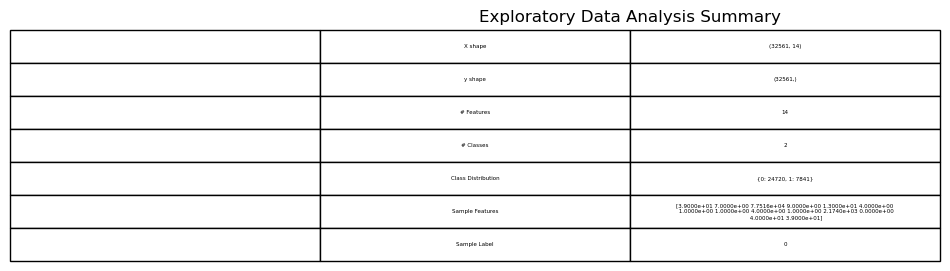


Training multiple Random Forests with diverse hyperparameters for rule extraction...

One-hot encoding 8 categorical features...
  Original features: 14, After one-hot encoding: 108
  One-hot mapping created for 102 encoded features
  Quantitative feature mapping: 6 features
  Trained RF 1: n_estimators=10, max_depth=3, random_state=42
    Tree depths: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  Trained RF 2: n_estimators=10, max_depth=5, random_state=42
    Tree depths: [5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  Trained RF 3: n_estimators=10, max_depth=7, random_state=42
    Tree depths: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Trained RF 4: n_estimators=10, max_depth=None, random_state=42
    Tree depths: [52, 55, 61, 55, 53, 64, 68, 54, 70, 62]
  Trained RF 5: n_estimators=20, max_depth=4, random_state=42
    Tree depths: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  Trained RF 6: n_estimators=20, max_depth=8, random_state=42
    Tree depths: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,

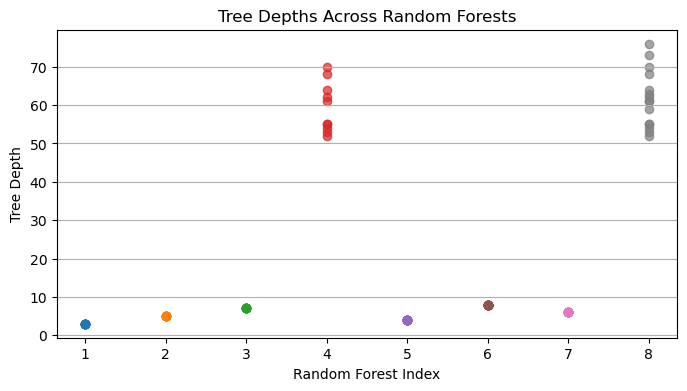


Summary: Trained 8 random forests with varying hyperparameters.
  RF 1: n_estimators=10, tree depths=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
  RF 2: n_estimators=10, tree depths=[5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
  RF 3: n_estimators=10, tree depths=[7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  RF 4: n_estimators=10, tree depths=[52, 55, 61, 55, 53, 64, 68, 54, 70, 62]
  RF 5: n_estimators=20, tree depths=[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
  RF 6: n_estimators=20, tree depths=[8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  RF 7: n_estimators=15, tree depths=[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
  RF 8: n_estimators=15, tree depths=[52, 55, 61, 55, 53, 64, 68, 54, 70, 62, 61, 63, 76, 73, 59]

Extracting rules from all decision trees in all forests...


KeyboardInterrupt: 

In [13]:
# HEROS hyperparameters for Adult dataset -----------------------------------------------------
outcome_type = "class"

iterations_adult = 20000
pop_size_adult = 500

model_iterations_adult = 100
model_pop_size_adult = 50

rule_pop_init_adult = "dt - verbose"
model_pop_init_adult = "top_rules"
fitness_function_adult = "pareto"
feat_track_adult = None

# Instantiate HEROS for Adult dataset ---------------------------------------------------------
heros_adult = HEROS(
    outcome_type=outcome_type,
    iterations=iterations_adult,
    pop_size=pop_size_adult,
    model_iterations=model_iterations_adult,
    model_pop_size=model_pop_size_adult,
    rule_pop_init=rule_pop_init_adult,
    model_pop_init=model_pop_init_adult,
    fitness_function=fitness_function_adult,
    feat_track=feat_track_adult,
    random_state=random_state,
    verbose=True,
)

# Make a copy so we don't mutate the original
X_adult_encoded_df = X_adult_df.copy()

# Encode only the categorical columns
for col in categorical_cols_adult:
    X_adult_encoded_df[col] = pd.Categorical(X_adult_encoded_df[col]).codes

# Convert to float numpy array for HEROS
X_adult = X_adult_encoded_df.to_numpy(dtype=float)
row_id_adult = None
ek_adult = None

# Fit HEROS on Adult dataset ------------------------------------------------------------------
heros_adult = heros_adult.fit(
    X_adult,
    y_adult,
    row_id_adult,
    cat_feat_indexes=cat_feat_indexes_adult,
    ek=ek_adult,
)

print("\nHEROS training on Adult dataset complete.")

# Optional: explicit tree_init_population test -----------------------------------------------
try:
    print("\nRunning explicit tree_init_population on Adult dataset...")
    heros_adult.rule_population.tree_init_population(
        X_adult_df,  # DataFrame with mixed numeric + categorical columns
        y_adult,
        heros_adult,
        random,
        np,
        verbose=True,
    )
    print("tree_init_population (Adult) finished.")
except AttributeError as e:
    print("tree_init_population method not found on heros_adult.rule_population. Skipping explicit call.")
    print("Error:", e)

# Optional: Inspect rule population summary ---------------------------------------------------
if hasattr(heros_adult, "rule_population"):
    rp_a = heros_adult.rule_population
    if hasattr(rp_a, "rule_pop_df"):
        print("\nFirst 10 rules from Adult rule population:")
        display(rp_a.rule_pop_df.head(10))


## Next Steps / TODOs

- **Tune hyperparameters** (`iterations`, `pop_size`, `model_iterations`, etc.) to match the settings in your main `HEROS_Demo_Notebook.ipynb` or your current experiment pipeline.
- Add **assertions or unit-test style checks** on:
  - The number of initialized rules.
  - The presence of expected categorical constraints (e.g., category-aggregated conditions).
  - Rule coverage and training accuracy for sanity checks.
- Extend this notebook to compare:
  - Tree-based initialization vs. random initialization,
  - Performance on categorical-only vs. mixed-type datasets.

This notebook is intentionally kept self-contained so you can quickly adapt it while developing and debugging your **categorical tree initialization** for HEROS.
